In [1]:
include("PermBasis.jl")
include("MonteCarloMF.jl")

using Base.Threads
using DifferentialEquations
using JLD2


simulate_ensemble_sampled (generic function with 1 method)

In [33]:

N = 2000000
Γ = 1.0
ξ = 0.01 * N
γ = 0.01 * N / log(N)

N_traj = 500
nsave = 1000
tmax = 3.0 * log(N) / (N * Γ)

I = (S, M, N, Γ, ξ) -> (S + M) * (S - M + 1.0)

@time t_exact, I_exact = simulate_ensemble_sampled(N, Γ, ξ, γ, tmax, I, N_traj)
@time t_tau, I_tau = simulate_ensemble_tau(N, Γ, ξ, γ, tmax, I, N_traj; nsave = length(t_exact), ε = 0.03, min_expected_events = 20.0)



 13.706398 seconds (64.90 k allocations: 42.554 MiB, 0.11% gc time, 0.33% compilation time)
  0.556601 seconds (109.84 k allocations: 45.013 MiB, 3.58% gc time, 9.54% compilation time)


([0.0, 2.1765163124098734e-9, 4.353032624819747e-9, 6.529548937229621e-9, 8.706065249639494e-9, 1.0882581562049368e-8, 1.3059097874459241e-8, 1.5235614186869114e-8, 1.7412130499278987e-8, 1.9588646811688864e-8  …  2.1743397960974638e-5, 2.1745574477287046e-5, 2.1747750993599458e-5, 2.1749927509911866e-5, 2.1752104026224278e-5, 2.1754280542536686e-5, 2.1756457058849098e-5, 2.1758633575161506e-5, 2.1760810091473918e-5, 2.1762986607786326e-5], [2.0e6, 2.00398792e6, 2.011975476e6, 2.015963336e6, 2.03595082e6, 2.047938212e6, 2.055925912e6, 2.063912964e6, 2.083899776e6, 2.087886868e6  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

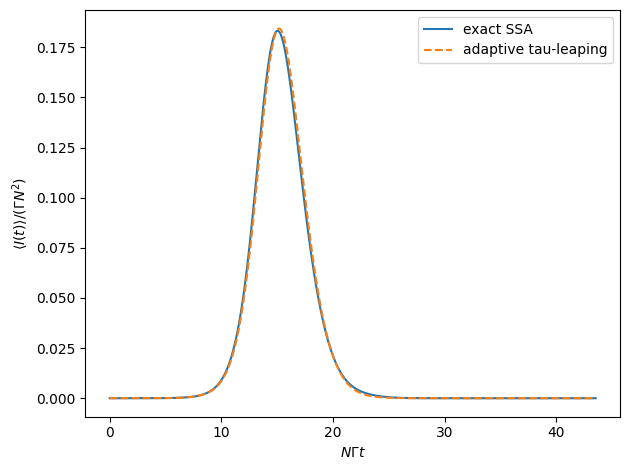

In [34]:
using PyPlot
figure()
plot(N .* Γ .* t_exact, I_exact ./ (Γ * N^2); label = "exact SSA")
plot(N .* Γ .* t_tau, I_tau ./ (Γ * N^2); label = "adaptive tau-leaping", ls = "--")

xlabel(L"N\Gamma t")
ylabel(L"\langle I(t)\rangle/(\Gamma N^2)")
legend()
tight_layout()

In [40]:
N = 10000000000
Γ = 1.0
ξ = 0.01 * N
γ = 0.01 * N / log(N)

N_traj = 100
nsave = 1000
tmax = 3.0 * log(N) / (N * Γ)

I = (S, M, N, Γ, ξ) -> (S + M) * (S - M + 1.0)
@time t_tau, I_tau = simulate_ensemble_tau(N, Γ, ξ, γ, tmax, I, N_traj; nsave = length(t_exact), ε = 0.03, min_expected_events = 20.0)

  0.193216 seconds (110.00 k allocations: 13.804 MiB, 32.26% compilation time)


([0.0, 6.908446123594496e-13, 1.3816892247188992e-12, 2.0725338370783488e-12, 2.7633784494377985e-12, 3.4542230617972482e-12, 4.1450676741566975e-12, 4.835912286516148e-12, 5.526756898875597e-12, 6.217601511235046e-12  …  6.901537677470902e-9, 6.902228522083261e-9, 6.9029193666956205e-9, 6.90361021130798e-9, 6.9043010559203394e-9, 6.904991900532699e-9, 6.905682745145058e-9, 6.906373589757418e-9, 6.907064434369777e-9, 6.907755278982137e-9], [1.0e10, 9.99993996992e9, 1.00998787019e10, 1.009981807352e10, 1.009975743462e10, 1.009969683306e10, 1.019963265248e10, 1.01995714876e10, 1.019951031506e10, 1.019944914098e10  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])